In [1]:
!pip install opencv_python

In [2]:
import cv2

In [3]:
!pip install nltk
!pip install tensorflow
!pip install keras
!pip install pillow

In [4]:
import nltk
import tensorflow
import keras

In [5]:
import os

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
import cv2

img = cv2.imread("/content/photo.jpg")

if img is None:
    print("Image 'img' was not loaded. Please check the file path.")
else:
    print("Image shape:", img.shape)

Image 'img' was not loaded. Please check the file path.


In [18]:
from google.colab import files

uploaded = files.upload()

Saving WhatsApp Image 2026-09-24 at 11.37.16 AM.jpeg to WhatsApp Image 2026-09-24 at 11.37.16 AM (1).jpeg


In [19]:
import cv2

filename = list(uploaded.keys())[0]

img = cv2.imread(filename)

print("Image shape:", img.shape)

Image shape: (1536, 1024, 3)


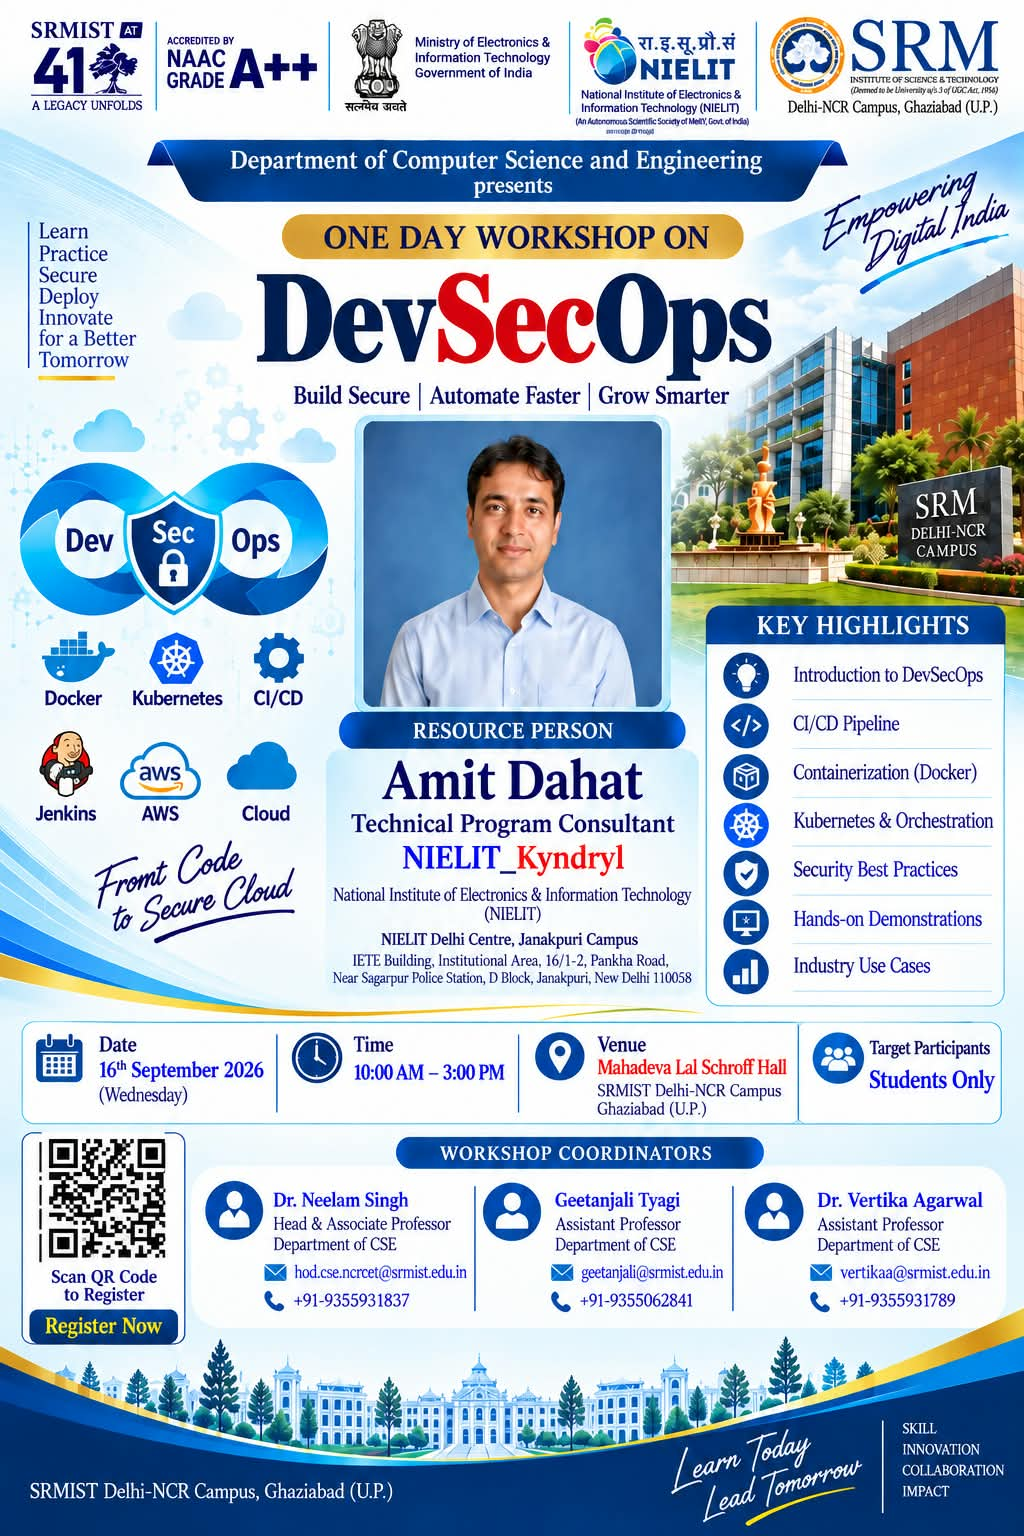

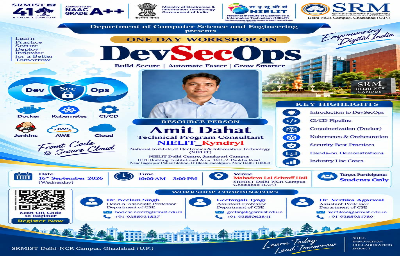

In [23]:
import cv2
from google.colab.patches import cv2_imshow

# Original image
cv2_imshow(img)

# Resize image
img_resize = cv2.resize(img, (400, 256))

# Resized image
cv2_imshow(img_resize)

In [24]:
!pip install ultralytics opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 795.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.0/90.0 kB 7.9 MB/s eta 0:00:00


In [26]:


import cv2
from ultralytics import settings

# Disable data and crash report tracking
settings.update({"sync": False})
from ultralytics import YOLO

# 1. Load the lightweight YOLOv8 Nano model (~6MB, runs fast on CPU)
model = YOLO('yolov8n.pt')

# 2. Open the webcam (0 is default built-in camera)
cap = cv2.VideoCapture(0)

print("Starting Object Counter... Press 'q' on the video window to quit.")

while cap.isOpened():
  success, frame = cap.read()
  if not success:
    print("Failed to grab camera frame.")
    break

  # 3. Perform object detection on the current frame
  results = model(frame, verbose=False)

  # Get total number of objects detected in this frame
  detected_count = len(results[0].boxes)

  # 4. Render detection boxes directly on the frame
  annotated_frame = results[0].plot()

  # 5. Display the object count overlay on screen
  cv2.putText(
      annotated_frame,
      f'Total Objects Counted: {detected_count}',
      (20, 50),  # Position (x, y)
      cv2.FONT_HERSHEY_SIMPLEX,
      1,  # Font scale
      (0, 255, 0),  # Text color (Green)
      2,  # Thickness
      cv2.LINE_AA,
  )

  # 6. Show the frame in a window
  cv2.imshow('BCA AI Demo - Live Object Counter', annotated_frame)

  # 7. Terminate program cleanly when pressing 'q'
  if cv2.waitKey(1) & 0xFF == ord('q'):
    print("Terminating program...")
    break

# Release camera and close all windows cleanly
cap.release()

# 2. Add short wait key loops to let Windows pump destroy events cleanly
# cv2.waitKey(1)
# cv2.destroyAllWindows()
# cv2.waitKey(1)

print("Camera feed closed successfully.")

Starting Object Counter... Press 'q' on the video window to quit.
Camera feed closed successfully.
